## **Lecture 4 Unsupervised Learning: Clustering**

- data driven identification of groups of things in the data

- who is our customer? How should we segment groups in our customers?

- Clustering naturally find groups in the data set (unbiased)

**Main use case** Generally, decide what data i want to look at (behaviour, demographic, embeddings), clustering model will create clusters (who are the people who are similar to each other), then I have to do the analysis of what makes them similar, then decide what to do with them (is this a useable segment? should I treat them differently?)

**anomaly detection** figure out groups of fraudlent transactions to inform the heuristics to create to block them, maintenance or downtime of servers cluster to analyze downtime incidents (risk to business model because clients aren't able to use the service)

fuzzy clustering is used commonly in NLP

similarity can be based on many things (autocorrect is looking at the closest word to what you wrote)


k-means works well if the data is convex (globular data); can't assess this from exploratory analysis

k-means creates clusters of equal variance

k-means doesn't care about density

k-means is a variance based algorithm and cannot ignore outliers; outliers will influence the placement of centroids

DBSCAN are sort of like a 3D view, areas that have lots of data points on top of each other is considered dense (this is a single of similarity for clustering algorithms, data on the margins doesn't exhibit the same type of behaviour); works well with unequal variance

DBSCAN is really good at ignoring outliers

mean-shift is a solution to non-globular shapes (good for oblong shapes)

expectation maximization clustering is biased because it assumes data is normally distributed

Agglomerative hierarchical clustering allows the analyst to access different levels of clusters; downside is i don't know how far apart certain levels of clusters will be; applications in biology (gene sequencing)

Affinity propogation converges data points together to create clusters



agglomerative clustering is inefficient; no hyperparameters; useful for exploratory analysis to determine if clustering is worthwhile to analyze the data (how does the data divide into clusters)

- Use silhouette scores when clustering 4 or more dimensions

There are no defined evaluation metrics in clustering

- Elbow method
    - The number of clusters is the hyperparameter to tune for k-means

- Silhouette analysis
    - Look at the coefficient instead of the plot (plot is confusing)

### **class example**

In [2]:
# electricity usage time series data set
# 368 customers, observations of 15 minute intervals over 3 years
# certain times are more expensive than others for electricity usage (supply/demand)

# can figure out common usage patterns with clustering

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import fileinput

In [4]:
with fileinput.FileInput('//Users/lucasben/Documents/mba-business-analytics/courses/machine-learning/assignment2-data/LD2011_2014.txt', inplace=True) as file:
  for line in file:
    print(line.replace(',','.'), end='')

In [5]:
df = pd.read_csv('//Users/lucasben/Documents/mba-business-analytics/courses/machine-learning/assignment2-data/LD2011_2014.txt', sep=';', index_col=0)
df.head()

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
sample = df.loc['2012-01-01 00:15:00':'2012-01-03 00:00:00'][['MT_001','MT_002']]# creating a quick sample

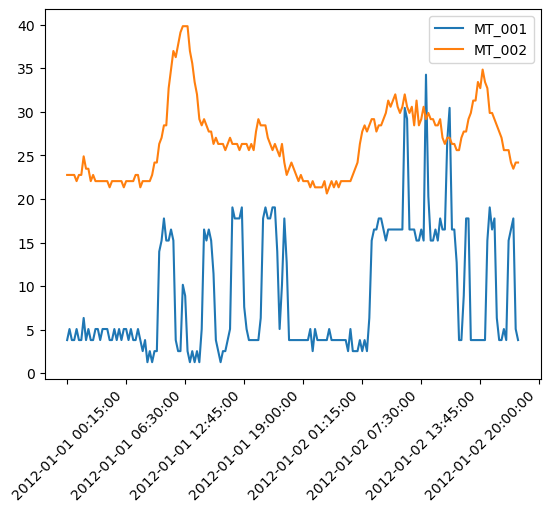

In [9]:
sample.plot()
plt.xticks(rotation=45);

In [11]:
# separating the years
data2011 = df.loc['2011-01-01 00:15:00':'2012-01-01 00:00:00']
data2012 = df.loc['2012-01-01 00:15:00':'2013-01-01 00:00:00']
data2013 = df.loc['2013-01-01 00:15:00':'2014-01-01 00:00:00']
data2014 = df.loc['2014-01-01 00:15:00':'2015-01-01 00:00:00']

In [12]:
# identifying times that didn't have any demand
clients = data2011.columns
clients_no_demand = clients[data2013.mean() == 0]
data_13_14 = pd.concat([data2013, data2014], axis=0)
data_13_14.drop(clients_no_demand , axis=1, inplace=True)

In [13]:
# next step is normalizing the data
# creating 24-hour curve per client (to look at 2-year average for a client)
df['hour'] = df.index.map(lambda x: x[11:]) # column that give us the hour of the day

In [14]:
# for every client we're going to get 96 rows because there are 96 15-minute intervals per day
data_13_14['hour'] = data_13_14.index.map(lambda x: x[11:])

In [15]:
avg_curves = data_13_14.groupby('hour').mean() # new data set

In [16]:
# now we can normalize them ; take the average of each client and divide it by the average overall
avg_curves_norm = avg_curves / (avg_curves.mean())

<Axes: xlabel='hour'>

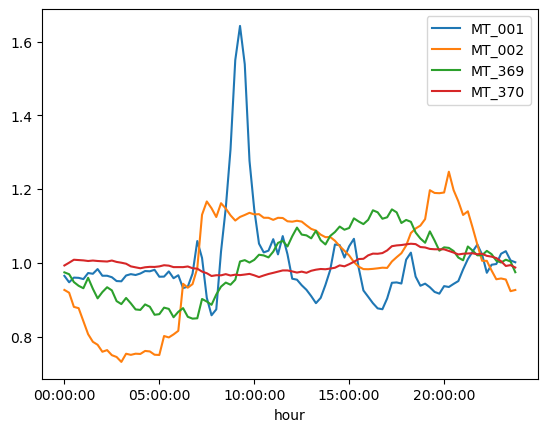

In [19]:
# clustering on pattern of usage (trends); we lose the ability to see the amount of elecriticity used after normalizing
avg_curves_norm[['MT_001', 'MT_002', 'MT_369', 'MT_370']].plot()

In [21]:
# converting the data frame into an array in order to feed it into a ML model
# every client becomes a dimension in the array
X = avg_curves_norm.copy()
X = np.array(X.T)
X

array([[0.96479215, 0.94737834, 0.96010381, ..., 1.03176835, 1.00665227,
        1.00162906],
       [0.92667365, 0.91911689, 0.8807438 , ..., 0.95492484, 0.9233459 ,
        0.92656966],
       [0.99179969, 0.97779638, 0.9765787 , ..., 1.00397648, 0.99849693,
        0.99301737],
       ...,
       [1.17044059, 1.22381837, 1.21134255, ..., 1.17431116, 1.15378816,
        1.13637963],
       [0.97430716, 0.96926554, 0.94796904, ..., 1.00867049, 1.00368029,
        0.97461078],
       [0.99296729, 1.00054813, 1.00851498, ..., 0.99165659, 0.99394714,
        0.98743097]])

In [22]:
# defining our intertia for later
def getInertia(X, kmeans):
  inertia = 0
  for J in range(len(X)):
    inertia = inertia + np.linalg.norm(X[J] - kmeans.cluster_centers_[kmeans.labels_[J]])**2
  return inertia

In [ ]:
# hyper parameter tuning 
inertia_1 = []
silhouette_avgs = []
max_K = 20

for k in np.arange(1, max_K+1):
  kmeans = KMeans(n_clusters=k, random_state=0).fit(X)
  inertia_1.append(getInertia(X, kmeans))
  if k > 1:
    silhouette_avgs = silhouette_avgs + [silhouette_score(X, kmeans.labels_)]

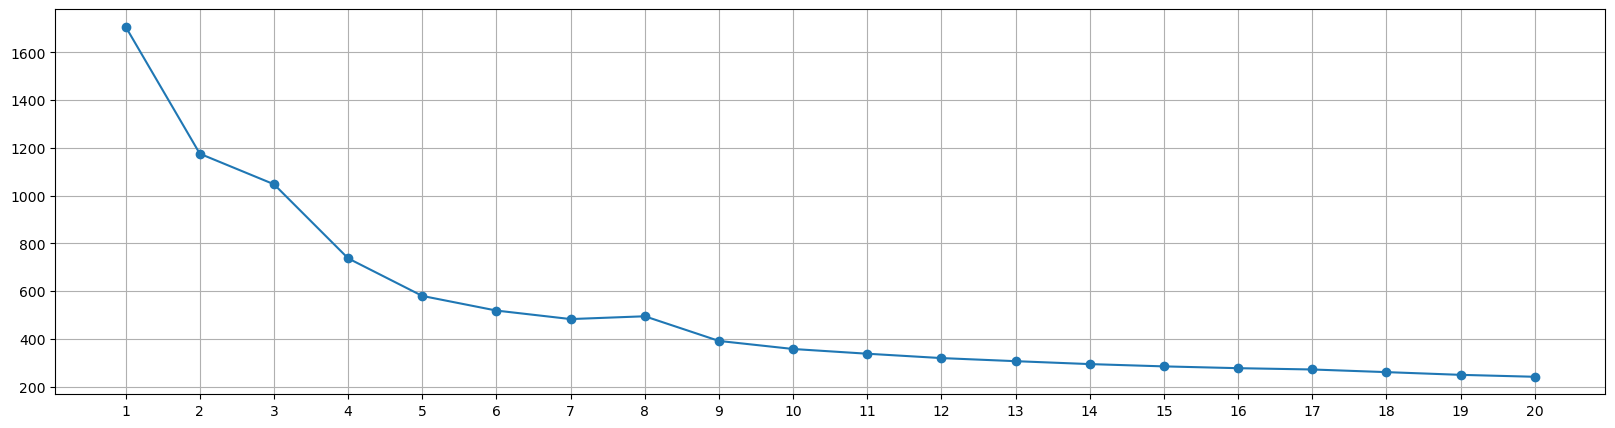

In [ ]:
plt.figure(figsize = (20,5))
plt.plot(np.arange(1, max_K+1), inertia_1, 'o-')
plt.xticks(np.arange(1,max_K+1))
plt.grid();
# k = 5 is an appropriate cutoff 

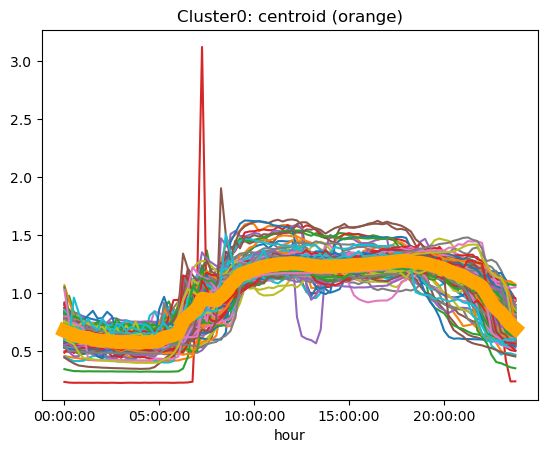

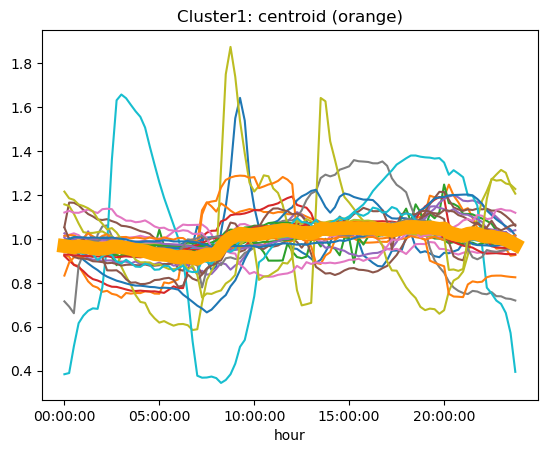

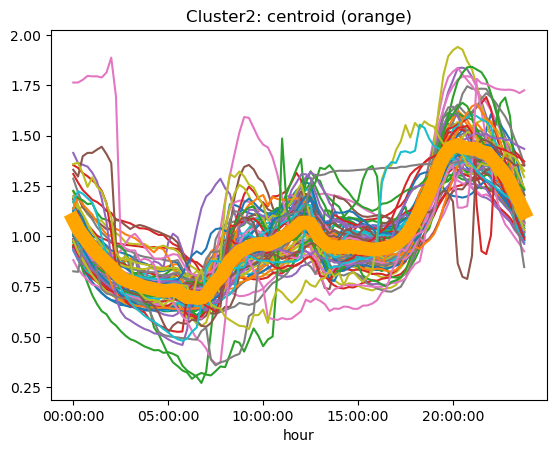

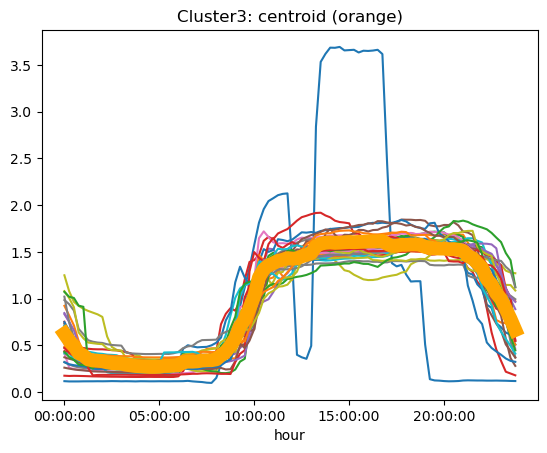

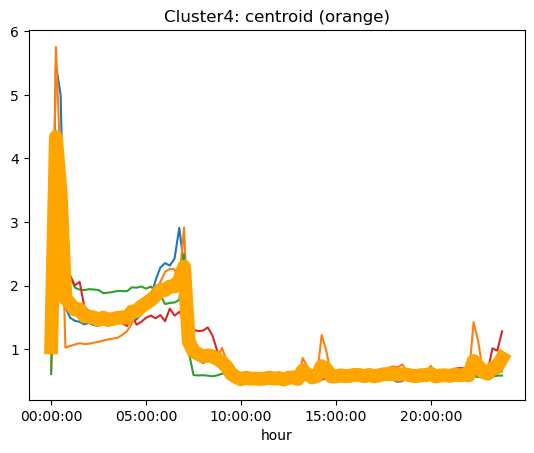

In [27]:
# building our model with 5 clusters
K = 5

kmeans = KMeans(n_clusters=K, random_state=0).fit(X)

for c in range(K):
    avg_curves_norm.T[kmeans.labels_ == c].T.plot(legend=False)
    plt.plot(kmeans.cluster_centers_[c], linewidth=10, color='orange')
    plt.title('Cluster'+str(c)+": centroid (orange)")
    plt.show()

#### **Next Example**

**Looking at weekdays versus weekends**

-  going to cluster days instead of customers (cluster which days are similar behaviour)

- cluster one customer and compare all of their different days

In [28]:
client = 'MT_022'

oneClient = data_13_14[client]

X = []
for J in range(2*365):
    X.extend([np.array(oneClient[J*96:(J+1)*96])])

In [ ]:
X # don't need to look at normalized curves because we're just looking at one customer
# this becomes the training data

[array([31.13325031, 28.64259029, 27.39726027, 24.90660025, 24.28393524,
        26.15193026, 26.15193026, 24.90660025, 26.77459527, 23.66127024,
        23.66127024, 21.17061021, 23.03860523, 19.30261519, 18.67995019,
        18.67995019, 19.30261519, 19.30261519, 18.67995019, 19.30261519,
        18.05728518, 18.05728518, 17.43462017, 16.81195517, 17.43462017,
        17.43462017, 17.43462017, 17.43462017, 18.67995019, 21.17061021,
        19.30261519, 20.54794521, 19.9252802 , 21.17061021, 20.54794521,
        21.79327522, 24.90660025, 31.13325031, 23.66127024, 19.30261519,
        21.79327522, 20.54794521, 13.69863014, 16.81195517, 15.56662516,
        18.05728518, 18.05728518, 16.81195517, 19.9252802 , 16.81195517,
        18.05728518, 20.54794521, 16.81195517, 18.67995019, 21.17061021,
        19.9252802 , 16.81195517, 16.18929016, 17.43462017, 18.05728518,
        18.67995019, 15.56662516, 18.05728518, 19.30261519, 18.05728518,
        15.56662516, 17.43462017, 18.05728518, 16.1

In [30]:
data_13_14['MT_022']

2013-01-01 00:15:00    31.133250
2013-01-01 00:30:00    28.642590
2013-01-01 00:45:00    27.397260
2013-01-01 01:00:00    24.906600
2013-01-01 01:15:00    24.283935
                         ...    
2014-12-31 23:00:00    31.133250
2014-12-31 23:15:00    34.246575
2014-12-31 23:30:00    36.114570
2014-12-31 23:45:00    34.246575
2015-01-01 00:00:00    31.133250
Name: MT_022, Length: 70080, dtype: float64

In [31]:
from datetime import date, timedelta
d1 = date(2013, 1, 1)
d2 = date(2014, 12, 31)

delta = d2 - d1
daysyear = []

D = {0:'mon', 1:'tues', 2:'wed', 3:'thurs', 4:'fri', 5:'sat', 6:'sun'}

for i in range(delta.days + 1):
  daysyear.extend([D[(d1 + timedelta(days=i)).weekday()] + '-'+str(d1+timedelta(days=i))])

In [35]:
inertias_1 = []
silhouette_avgs = []
max_K = 15

for k in np.arange(1,max_K+1):
  kmeans = KMeans(n_clusters=k, random_state=0).fit(X)
  inertias_1 = inertias_1 + [kmeans.inertia_]
  if k>1:
    silhouette_avgs = silhouette_avgs + [silhouette_score(X, kmeans.labels_)]

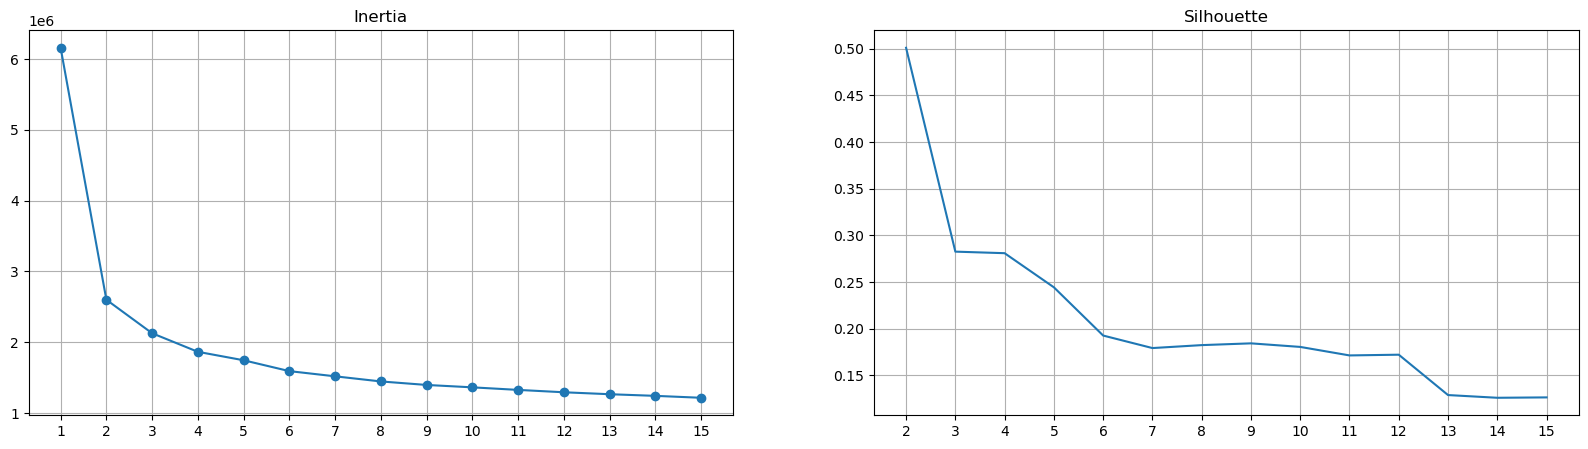

In [36]:
plt.figure(figsize=(20,5))

plt.subplot(1,2,1)

plt.title("Inertia")
plt.plot(np.arange(1,max_K+1), inertias_1, 'o-')
plt.xticks(np.arange(1,max_K+1))
plt.grid()

plt.subplot(1,2,2)
plt.title('Silhouette')
plt.plot(np.arange(2,max_K+1),silhouette_avgs)
plt.xticks(np.arange(2,max_K+1))
plt.grid()

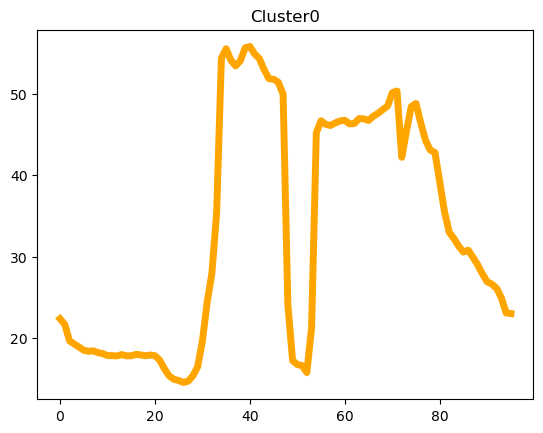

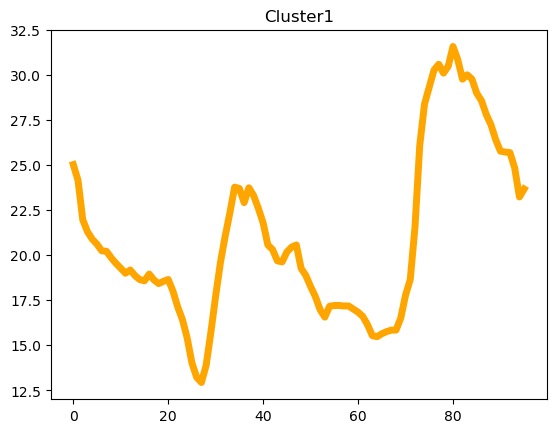

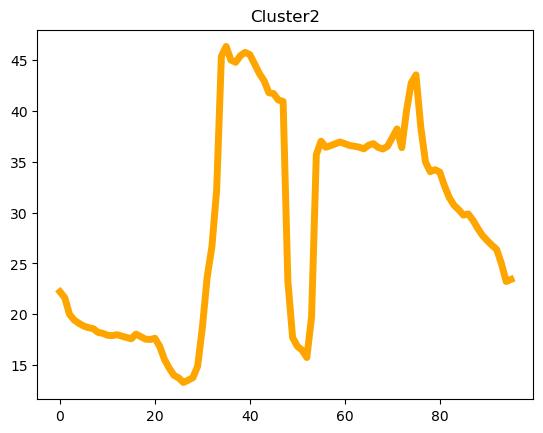

In [ ]:
K = 3
kmeans = KMeans(n_clusters=K, random_state=0).fit(X)

for c in range(K):
  plt.plot(kmeans.cluster_centers_[c], linewidth=5, color='orange')
  plt.title('Cluster'+str(c))
  plt.show()

# x is time in 15-minute intervals
# y is watts used 
# 3 distinct patterns of how a person averagely uses electricity daily at their home over 2 years

In [39]:
from itertools import compress
weekdays = []
for i in range(delta.days + 1):
  weekdays.extend([D[(d1 + timedelta(days=i)).weekday()]])

weekdays_CL0 = list(compress(weekdays, (kmeans.labels_ == 0)))
weekdays_CL1 = list(compress(weekdays, (kmeans.labels_ == 1)))
weekdays_CL2 = list(compress(weekdays, (kmeans.labels_ == 2)))

In [ ]:
from collections import Counter
print(Counter(weekdays_CL0))
print(Counter(weekdays_CL1))
print(Counter(weekdays_CL2))
# we found a real insight about weekday and weekend energy usage

Counter({'thurs': 59, 'mon': 59, 'tues': 54, 'wed': 51, 'fri': 46, 'sat': 5})
Counter({'sun': 104, 'sat': 48, 'tues': 11, 'wed': 11, 'fri': 10, 'thurs': 10, 'mon': 9})
Counter({'sat': 51, 'fri': 48, 'wed': 43, 'tues': 40, 'mon': 36, 'thurs': 35})
